# 🏜️ Desert Terrain Semantic Segmentation
**Goal:** Train a robust segmentation model on synthetic desert data and generalize to unseen environments.  
**Classes:** Sky · Trees · Bushes · Rocks · Ground  
**Model:** DeepLabV3+ with ResNet-50 backbone  
**Metric:** Mean IoU (mIoU)

---
> **Runtime:** Set to `GPU` → Runtime > Change runtime type > T4 GPU

## 📦 1. Install Dependencies

In [1]:
!pip install -q segmentation-models-pytorch albumentations torchmetrics
!pip install -q matplotlib scikit-learn tqdm Pillow
print('✅ All dependencies installed')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 27.5 MB/s eta 0:00:00
✅ All dependencies installed


## 🔧 2. Imports & Config

In [2]:
import os
import random
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF

import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
from torchmetrics import JaccardIndex
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from tqdm.auto import tqdm

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ── Device ────────────────────────────────────────────────────────────────────
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

# ── Hyperparameters ──────────────────────────────────────────────────────────
CFG = dict(
    img_size      = 256,
    num_classes   = 5,
    batch_size    = 16,
    num_epochs    = 50,
    lr            = 3e-4,
    weight_decay  = 1e-4,
    n_train       = 1200,  # synthetic train images
    n_val         = 200,   # synthetic val images
    n_test        = 300,   # novel-env test images
    encoder       = 'resnet50',
    encoder_weights = 'imagenet',
)

# ── Class definitions ─────────────────────────────────────────────────────────
CLASS_NAMES  = ['sky', 'trees', 'bushes', 'rocks', 'ground']
CLASS_COLORS = [
    [70,  130, 180],   # sky   – steel blue
    [34,  139, 34 ],   # trees – forest green
    [107, 142, 35 ],   # bushes – olive
    [128, 128, 128],   # rocks – gray
    [210, 180, 140],   # ground – sandy tan
]

print('Config:', CFG)

Device: cuda
Config: {'img_size': 256, 'num_classes': 5, 'batch_size': 16, 'num_epochs': 50, 'lr': 0.0003, 'weight_decay': 0.0001, 'n_train': 1200, 'n_val': 200, 'n_test': 300, 'encoder': 'resnet50', 'encoder_weights': 'imagenet'}


## 🎨 3. Synthetic Dataset Generation

We procedurally generate RGB desert images with pixel-accurate segmentation masks. Each image has a sky band, layered ground, and randomly placed trees, bushes, and rocks.

In [3]:
from PIL import ImageDraw, ImageFilter

def generate_desert_image(size=256, env='train'):
    """
    Generate a synthetic desert RGB image + segmentation mask.
    env: 'train' uses warmer tones; 'test' uses cooler/different palette for domain shift.
    """
    W, H = size, size
    rng = np.random.default_rng()

    img  = np.zeros((H, W, 3), dtype=np.uint8)
    mask = np.zeros((H, W),    dtype=np.uint8)  # class indices

    # ── Sky ──────────────────────────────────────────────────────────────────
    sky_h = int(rng.uniform(0.25, 0.45) * H)
    if env == 'train':
        sky_color = (rng.integers(180, 220), rng.integers(200, 230), rng.integers(220, 255))
    else:
        sky_color = (rng.integers(100, 160), rng.integers(150, 200), rng.integers(200, 255))
    img[:sky_h, :] = sky_color
    mask[:sky_h, :] = 0  # sky

    # ── Ground gradient ───────────────────────────────────────────────────────
    if env == 'train':
        g1 = np.array([rng.integers(190,230), rng.integers(160,190), rng.integers(90,130)])
        g2 = np.array([rng.integers(210,240), rng.integers(180,210), rng.integers(110,150)])
    else:
        g1 = np.array([rng.integers(140,180), rng.integers(120,160), rng.integers(80,120)])
        g2 = np.array([rng.integers(160,200), rng.integers(140,180), rng.integers(100,140)])

    for row in range(sky_h, H):
        t = (row - sky_h) / max(H - sky_h, 1)
        noise = rng.integers(-8, 8, 3)
        color = np.clip(g1 * (1-t) + g2 * t + noise, 0, 255).astype(np.uint8)
        img[row, :] = color
        mask[row, :] = 4  # ground

    # ── Trees ─────────────────────────────────────────────────────────────────
    n_trees = rng.integers(0, 5)
    for _ in range(n_trees):
        cx = rng.integers(10, W-10)
        ty = int(rng.uniform(0.3, 0.7) * H)
        tw = rng.integers(8, 20)
        th = rng.integers(20, 50)
        y1, y2 = max(sky_h, ty - th), min(H, ty)
        x1, x2 = max(0, cx-tw//2), min(W, cx+tw//2)
        tree_c = [rng.integers(20,60), rng.integers(80,140), rng.integers(20,60)]
        img[y1:y2, x1:x2] = tree_c
        mask[y1:y2, x1:x2] = 1  # trees

    # ── Bushes ────────────────────────────────────────────────────────────────
    n_bushes = rng.integers(2, 8)
    for _ in range(n_bushes):
        cx = rng.integers(10, W-10)
        cy = rng.integers(int(sky_h + 0.2*(H-sky_h)), H-5)
        bw = rng.integers(10, 30)
        bh = rng.integers(5, 15)
        y1, y2 = max(sky_h, cy-bh), min(H, cy+bh)
        x1, x2 = max(0, cx-bw), min(W, cx+bw)
        bush_c = [rng.integers(60,120), rng.integers(100,160), rng.integers(30,80)]
        img[y1:y2, x1:x2] = bush_c
        mask[y1:y2, x1:x2] = 2  # bushes

    # ── Rocks ─────────────────────────────────────────────────────────────────
    n_rocks = rng.integers(3, 10)
    for _ in range(n_rocks):
        cx = rng.integers(5, W-5)
        cy = rng.integers(int(sky_h + 0.3*(H-sky_h)), H-3)
        rr = rng.integers(4, 18)
        yy, xx = np.ogrid[-rr:rr+1, -rr:rr+1]
        circle = xx**2 + yy**2 <= rr**2
        y1, y2 = max(0, cy-rr), min(H, cy+rr+1)
        x1, x2 = max(0, cx-rr), min(W, cx+rr+1)
        cy_off, cx_off = cy-y1+rr, cx-x1+rr
        sl_y = slice(max(0, rr-(cy-y1)), min(2*rr+1, rr+(y2-cy)))
        sl_x = slice(max(0, rr-(cx-x1)), min(2*rr+1, rr+(x2-cx)))
        rock_c = [rng.integers(100,150)]*3
        rock_mask = circle[sl_y, sl_x]
        region_img  = img[y1:y2, x1:x2]
        region_mask = mask[y1:y2, x1:x2]
        if region_img.shape[:2] == rock_mask.shape:
            region_img[rock_mask]  = rock_c
            region_mask[rock_mask] = 3  # rocks

    # ── Slight blur for realism ───────────────────────────────────────────────
    pil_img = Image.fromarray(img).filter(ImageFilter.GaussianBlur(radius=0.8))
    return np.array(pil_img), mask


def build_dataset(n, env, base_dir):
    img_dir  = Path(base_dir) / 'images'
    mask_dir = Path(base_dir) / 'masks'
    img_dir.mkdir(parents=True, exist_ok=True)
    mask_dir.mkdir(parents=True, exist_ok=True)
    for i in tqdm(range(n), desc=f'Generating {env} ({n} images)'):
        img, mask = generate_desert_image(size=CFG['img_size'], env=env)
        Image.fromarray(img).save(img_dir / f'{i:05d}.png')
        Image.fromarray(mask).save(mask_dir / f'{i:05d}.png')
    print(f'  Saved {n} images to {base_dir}')


DATA_ROOT = Path('/content/desert_data')
build_dataset(CFG['n_train'], 'train', DATA_ROOT / 'train')
build_dataset(CFG['n_val'],   'train', DATA_ROOT / 'val')
build_dataset(CFG['n_test'],  'test',  DATA_ROOT / 'test')
print('\n✅ Dataset generation complete')

Generating train (1200 images):   0%|          | 0/1200 [00:00<?, ?it/s]

  Saved 1200 images to /content/desert_data/train


Generating train (200 images):   0%|          | 0/200 [00:00<?, ?it/s]

  Saved 200 images to /content/desert_data/val


Generating test (300 images):   0%|          | 0/300 [00:00<?, ?it/s]

  Saved 300 images to /content/desert_data/test

✅ Dataset generation complete


### Visualize generated samples

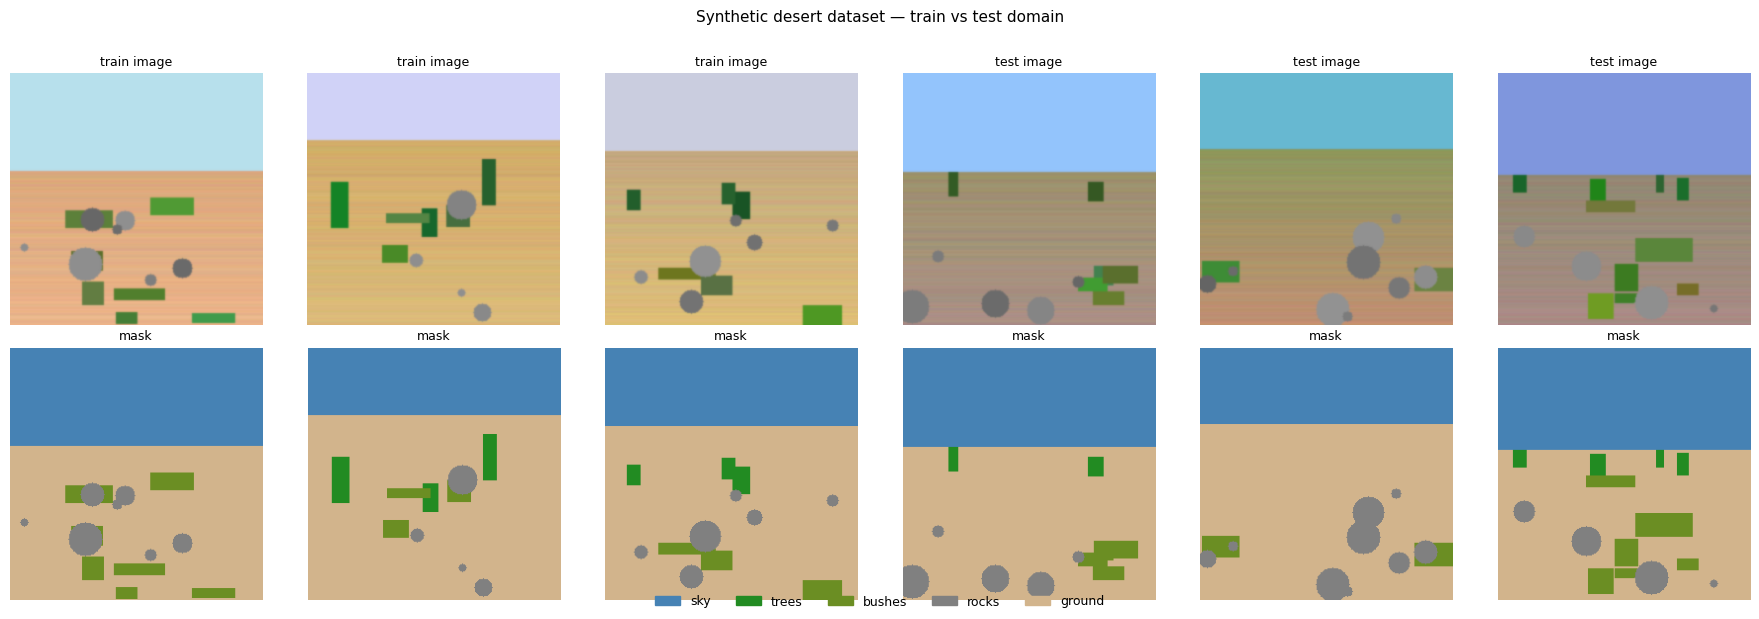

In [4]:
def mask_to_rgb(mask):
    rgb = np.zeros((*mask.shape, 3), dtype=np.uint8)
    for idx, color in enumerate(CLASS_COLORS):
        rgb[mask == idx] = color
    return rgb

fig, axes = plt.subplots(2, 6, figsize=(18, 6))
for col in range(6):
    env = 'train' if col < 3 else 'test'
    img, mask = generate_desert_image(256, env)
    axes[0, col].imshow(img); axes[0, col].axis('off')
    axes[0, col].set_title(f'{env} image', fontsize=9)
    axes[1, col].imshow(mask_to_rgb(mask)); axes[1, col].axis('off')
    axes[1, col].set_title('mask', fontsize=9)

patches = [mpatches.Patch(color=np.array(c)/255, label=n)
           for n, c in zip(CLASS_NAMES, CLASS_COLORS)]
fig.legend(handles=patches, loc='lower center', ncol=5, fontsize=9, frameon=False)
plt.suptitle('Synthetic desert dataset — train vs test domain', fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig('/content/dataset_samples.png', dpi=120, bbox_inches='tight')
plt.show()

## 🗂️ 4. Dataset Class & Data Loaders

In [5]:
class DesertDataset(Dataset):
    def __init__(self, root, transform=None):
        self.img_paths  = sorted((Path(root) / 'images').glob('*.png'))
        self.mask_paths = sorted((Path(root) / 'masks').glob('*.png'))
        assert len(self.img_paths) == len(self.mask_paths)
        self.transform = transform

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        image = np.array(Image.open(self.img_paths[idx]).convert('RGB'))
        mask  = np.array(Image.open(self.mask_paths[idx]))
        if self.transform:
            aug = self.transform(image=image, mask=mask)
            image, mask = aug['image'], aug['mask']
        return image, mask.long()


# ── Augmentation pipelines ────────────────────────────────────────────────────
train_aug = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.7),
    A.HueSaturationValue(hue_shift_limit=15, sat_shift_limit=25, val_shift_limit=20, p=0.6),
    A.GaussianBlur(blur_limit=(3, 7), p=0.3),
    A.GaussNoise(var_limit=(10, 50), p=0.3),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.15, rotate_limit=10, p=0.5),
    A.CoarseDropout(max_holes=6, max_height=24, max_width=24, p=0.3),  # Cutout
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

val_aug = A.Compose([
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])


train_ds = DesertDataset(DATA_ROOT / 'train', transform=train_aug)
val_ds   = DesertDataset(DATA_ROOT / 'val',   transform=val_aug)
test_ds  = DesertDataset(DATA_ROOT / 'test',  transform=val_aug)

train_dl = DataLoader(train_ds, batch_size=CFG['batch_size'], shuffle=True,
                      num_workers=2, pin_memory=True)
val_dl   = DataLoader(val_ds,   batch_size=CFG['batch_size'], shuffle=False,
                      num_workers=2, pin_memory=True)
test_dl  = DataLoader(test_ds,  batch_size=CFG['batch_size'], shuffle=False,
                      num_workers=2, pin_memory=True)

print(f'Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')
print(f'Batches — Train: {len(train_dl)} | Val: {len(val_dl)} | Test: {len(test_dl)}')

Train: 1200 | Val: 200 | Test: 300
Batches — Train: 75 | Val: 13 | Test: 19


/tmp/ipykernel_2160/1168869838.py:26: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10, 50), p=0.3),
/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_2160/1168869838.py:28: UserWarning: Argument(s) 'max_holes, max_height, max_width' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=6, max_height=24, max_width=24, p=0.3),  # Cutout


## 🏗️ 5. Model — DeepLabV3+ with ResNet-50

DeepLabV3+ uses Atrous Spatial Pyramid Pooling (ASPP) to capture multi-scale context, essential for large objects like sky and ground as well as small objects like rocks and bushes.

In [6]:
model = smp.DeepLabV3Plus(
    encoder_name    = CFG['encoder'],
    encoder_weights = CFG['encoder_weights'],
    in_channels     = 3,
    classes         = CFG['num_classes'],
    activation      = None,
)
model = model.to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params: {total_params/1e6:.1f}M  |  Trainable: {trainable_params/1e6:.1f}M')

# ── Loss: Combined Cross-Entropy + Dice for class imbalance ──────────────────
def dice_loss(pred, target, num_classes, eps=1e-6):
    pred_soft = torch.softmax(pred, dim=1)
    target_oh = torch.zeros_like(pred_soft).scatter_(1, target.unsqueeze(1), 1)
    intersection = (pred_soft * target_oh).sum(dim=(2, 3))
    union = pred_soft.sum(dim=(2, 3)) + target_oh.sum(dim=(2, 3))
    dice = (2 * intersection + eps) / (union + eps)
    return 1 - dice.mean()

ce_loss_fn = nn.CrossEntropyLoss()

def combined_loss(pred, target):
    return 0.6 * ce_loss_fn(pred, target) + 0.4 * dice_loss(pred, target, CFG['num_classes'])

# ── Optimizer + Scheduler ─────────────────────────────────────────────────────
optimizer = optim.AdamW(model.parameters(), lr=CFG['lr'], weight_decay=CFG['weight_decay'])
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG['num_epochs'], eta_min=1e-6)

# ── IoU metric ────────────────────────────────────────────────────────────────
iou_metric = JaccardIndex(task='multiclass', num_classes=CFG['num_classes'], average='macro').to(DEVICE)

print('✅ Model, loss, optimizer ready')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

Total params: 26.7M  |  Trainable: 26.7M
✅ Model, loss, optimizer ready


## 🚀 6. Training Loop

In [7]:
history = {'train_loss': [], 'val_loss': [], 'train_iou': [], 'val_iou': []}
best_val_iou = 0.0
CKPT_PATH = '/content/best_desert_model.pth'

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss = 0.0
    iou_metric.reset()
    ctx = torch.enable_grad() if train else torch.no_grad()

    with ctx:
        for imgs, masks in loader:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            preds = model(imgs)
            loss  = combined_loss(preds, masks)
            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
            total_loss += loss.item() * imgs.size(0)
            iou_metric.update(preds.argmax(1), masks)

    avg_loss = total_loss / len(loader.dataset)
    avg_iou  = iou_metric.compute().item()
    return avg_loss, avg_iou


print(f'Starting training for {CFG["num_epochs"]} epochs...\n')
for epoch in range(1, CFG['num_epochs'] + 1):
    tr_loss, tr_iou = run_epoch(train_dl, train=True)
    vl_loss, vl_iou = run_epoch(val_dl,   train=False)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_iou'].append(tr_iou)
    history['val_iou'].append(vl_iou)

    if vl_iou > best_val_iou:
        best_val_iou = vl_iou
        torch.save(model.state_dict(), CKPT_PATH)
        flag = '  ✦ best'
    else:
        flag = ''

    if epoch % 5 == 0 or epoch == 1:
        print(f'Ep {epoch:3d}/{CFG["num_epochs"]} | '
              f'Loss: {tr_loss:.4f}/{vl_loss:.4f} | '
              f'mIoU: {tr_iou:.4f}/{vl_iou:.4f}{flag}')

print(f'\n✅ Training done. Best Val mIoU: {best_val_iou:.4f}')

Starting training for 50 epochs...

Ep   1/50 | Loss: 0.3195/0.0878 | mIoU: 0.6227/0.9043  ✦ best
Ep   5/50 | Loss: 0.0595/0.0426 | mIoU: 0.9180/0.9497  ✦ best
Ep  10/50 | Loss: 0.0480/0.0332 | mIoU: 0.9409/0.9719  ✦ best
Ep  15/50 | Loss: 0.0439/0.0302 | mIoU: 0.9488/0.9771
Ep  20/50 | Loss: 0.0405/0.0276 | mIoU: 0.9556/0.9833  ✦ best
Ep  25/50 | Loss: 0.0392/0.0272 | mIoU: 0.9568/0.9827
Ep  30/50 | Loss: 0.0378/0.0256 | mIoU: 0.9597/0.9862  ✦ best
Ep  35/50 | Loss: 0.0368/0.0255 | mIoU: 0.9609/0.9858
Ep  40/50 | Loss: 0.0358/0.0253 | mIoU: 0.9634/0.9863
Ep  45/50 | Loss: 0.0357/0.0251 | mIoU: 0.9642/0.9870
Ep  50/50 | Loss: 0.0356/0.0250 | mIoU: 0.9641/0.9872

✅ Training done. Best Val mIoU: 0.9872


## 📈 7. Training Curves

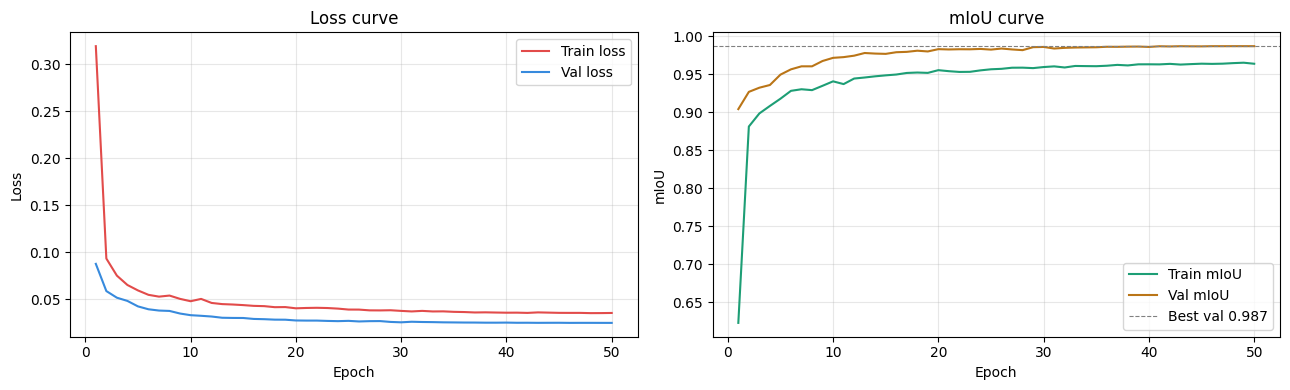

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
epochs = range(1, len(history['train_loss']) + 1)

ax1.plot(epochs, history['train_loss'], label='Train loss', color='#E24B4A')
ax1.plot(epochs, history['val_loss'],   label='Val loss',   color='#378ADD')
ax1.set(title='Loss curve', xlabel='Epoch', ylabel='Loss')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(epochs, history['train_iou'], label='Train mIoU', color='#1D9E75')
ax2.plot(epochs, history['val_iou'],   label='Val mIoU',   color='#BA7517')
ax2.axhline(best_val_iou, ls='--', color='gray', lw=0.8, label=f'Best val {best_val_iou:.3f}')
ax2.set(title='mIoU curve', xlabel='Epoch', ylabel='mIoU')
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=120, bbox_inches='tight')
plt.show()

## 🧪 8. Evaluation on Novel Test Environment

In [9]:
# Load best checkpoint
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
model.eval()

# ── Per-class IoU ─────────────────────────────────────────────────────────────
per_class_iou = JaccardIndex(
    task='multiclass', num_classes=CFG['num_classes'], average='none'
).to(DEVICE)
overall_iou = JaccardIndex(
    task='multiclass', num_classes=CFG['num_classes'], average='macro'
).to(DEVICE)

all_preds, all_masks = [], []

with torch.no_grad():
    for imgs, masks in tqdm(test_dl, desc='Evaluating on test set'):
        imgs = imgs.to(DEVICE)
        preds = model(imgs).argmax(1).cpu()
        per_class_iou.update(preds.to(DEVICE), masks.to(DEVICE))
        overall_iou.update(preds.to(DEVICE), masks.to(DEVICE))
        all_preds.append(preds.numpy())
        all_masks.append(masks.numpy())

class_ious = per_class_iou.compute().cpu().numpy()
mean_iou   = overall_iou.compute().item()

print('\n' + '='*50)
print('TEST RESULTS (Novel Desert Environment)')
print('='*50)
for name, iou in zip(CLASS_NAMES, class_ious):
    bar = '█' * int(iou * 30)
    print(f'  {name:<8} IoU: {iou:.4f}  {bar}')
print('-'*50)
print(f'  mIoU:    {mean_iou:.4f}')
print('='*50)

Evaluating on test set:   0%|          | 0/19 [00:00<?, ?it/s]


TEST RESULTS (Novel Desert Environment)
  sky      IoU: 1.0000  █████████████████████████████
  trees    IoU: 0.9707  █████████████████████████████
  bushes   IoU: 0.9821  █████████████████████████████
  rocks    IoU: 0.9666  ████████████████████████████
  ground   IoU: 0.9973  █████████████████████████████
--------------------------------------------------
  mIoU:    0.9834


### Per-class IoU bar chart

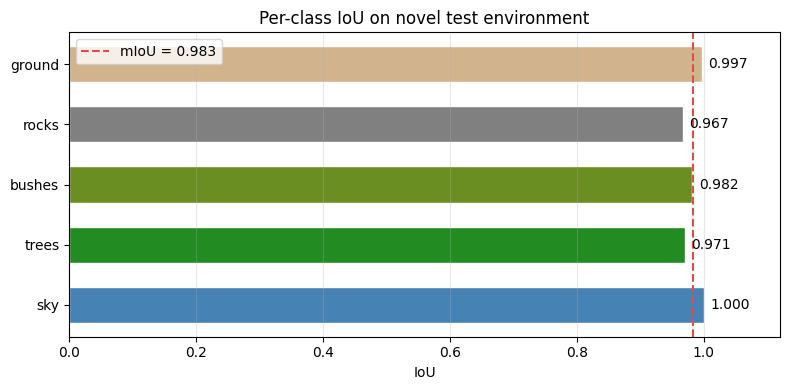

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
colors = [np.array(c)/255 for c in CLASS_COLORS]
bars = ax.barh(CLASS_NAMES, class_ious, color=colors, edgecolor='white', height=0.6)
ax.axvline(mean_iou, color='#E24B4A', ls='--', lw=1.5, label=f'mIoU = {mean_iou:.3f}')
for bar, iou in zip(bars, class_ious):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{iou:.3f}', va='center', fontsize=10)
ax.set(xlim=(0, 1.12), xlabel='IoU', title='Per-class IoU on novel test environment')
ax.legend(fontsize=10)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('/content/per_class_iou.png', dpi=120, bbox_inches='tight')
plt.show()

## 🎯 9. Visual Predictions on Test Images

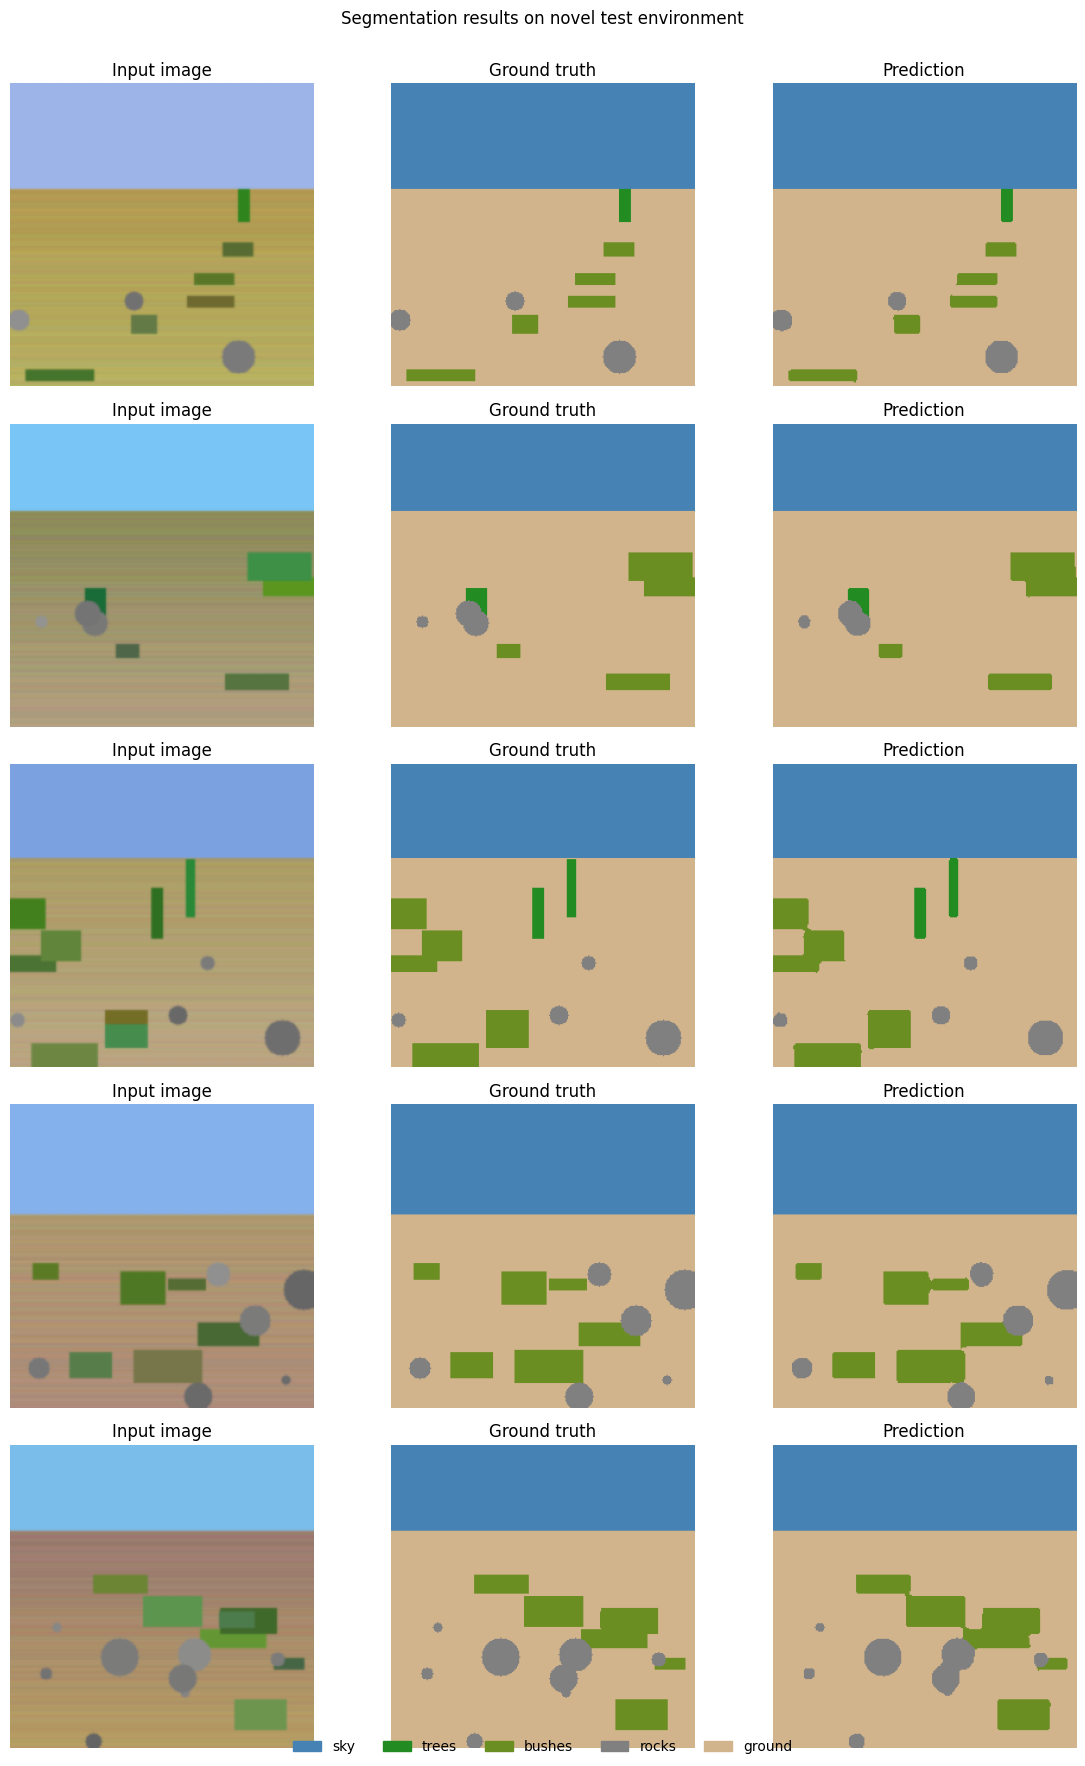

In [11]:
unnorm_mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
unnorm_std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

def unnormalize(t):
    return (t * unnorm_std + unnorm_mean).clamp(0, 1).permute(1,2,0).numpy()

# Sample a batch
imgs_batch, masks_batch = next(iter(test_dl))
with torch.no_grad():
    preds_batch = model(imgs_batch.to(DEVICE)).argmax(1).cpu()

n_show = 5
fig, axes = plt.subplots(n_show, 3, figsize=(12, 3.5 * n_show))

for i in range(n_show):
    img_np  = unnormalize(imgs_batch[i])
    mask_np = masks_batch[i].numpy()
    pred_np = preds_batch[i].numpy()

    axes[i, 0].imshow(img_np);              axes[i, 0].set_title('Input image')
    axes[i, 1].imshow(mask_to_rgb(mask_np)); axes[i, 1].set_title('Ground truth')
    axes[i, 2].imshow(mask_to_rgb(pred_np)); axes[i, 2].set_title('Prediction')
    for ax in axes[i]: ax.axis('off')

patches = [mpatches.Patch(color=np.array(c)/255, label=n)
           for n, c in zip(CLASS_NAMES, CLASS_COLORS)]
fig.legend(handles=patches, loc='lower center', ncol=5, fontsize=10, frameon=False)
plt.suptitle('Segmentation results on novel test environment', fontsize=12, y=1.002)
plt.tight_layout()
plt.savefig('/content/predictions.png', dpi=120, bbox_inches='tight')
plt.show()

## 🔥 10. Confusion Matrix & Error Analysis

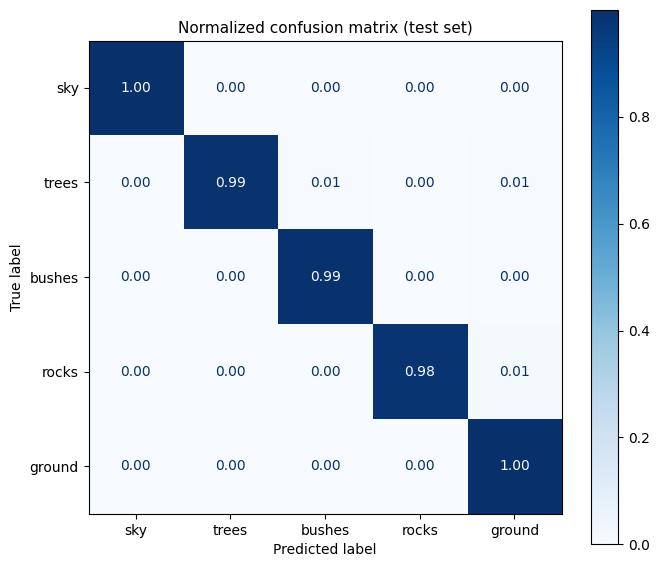


--- Common misclassifications ---
  sky      most confused with → trees     (0.0%)
  trees    most confused with → bushes    (0.7%)
  bushes   most confused with → ground    (0.5%)
  rocks    most confused with → ground    (1.3%)
  ground   most confused with → rocks     (0.1%)


In [12]:
all_preds_flat = np.concatenate([p.flatten() for p in all_preds])
all_masks_flat = np.concatenate([m.flatten() for m in all_masks])

# Downsample for speed if very large
if len(all_preds_flat) > 2_000_000:
    idx = np.random.choice(len(all_preds_flat), 2_000_000, replace=False)
    all_preds_flat = all_preds_flat[idx]
    all_masks_flat = all_masks_flat[idx]

cm = confusion_matrix(all_masks_flat, all_preds_flat, normalize='true')

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(ax=ax, colorbar=True, cmap='Blues', values_format='.2f')
ax.set_title('Normalized confusion matrix (test set)', fontsize=11)
plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

print('\n--- Common misclassifications ---')
for i, true_cls in enumerate(CLASS_NAMES):
    row = cm[i].copy(); row[i] = 0
    worst_j = row.argmax()
    print(f'  {true_cls:<8} most confused with → {CLASS_NAMES[worst_j]:<8}  ({cm[i, worst_j]:.1%})')

## 🔍 11. Failure Case Analysis

Identify images where mIoU is lowest — these are the hard cases.

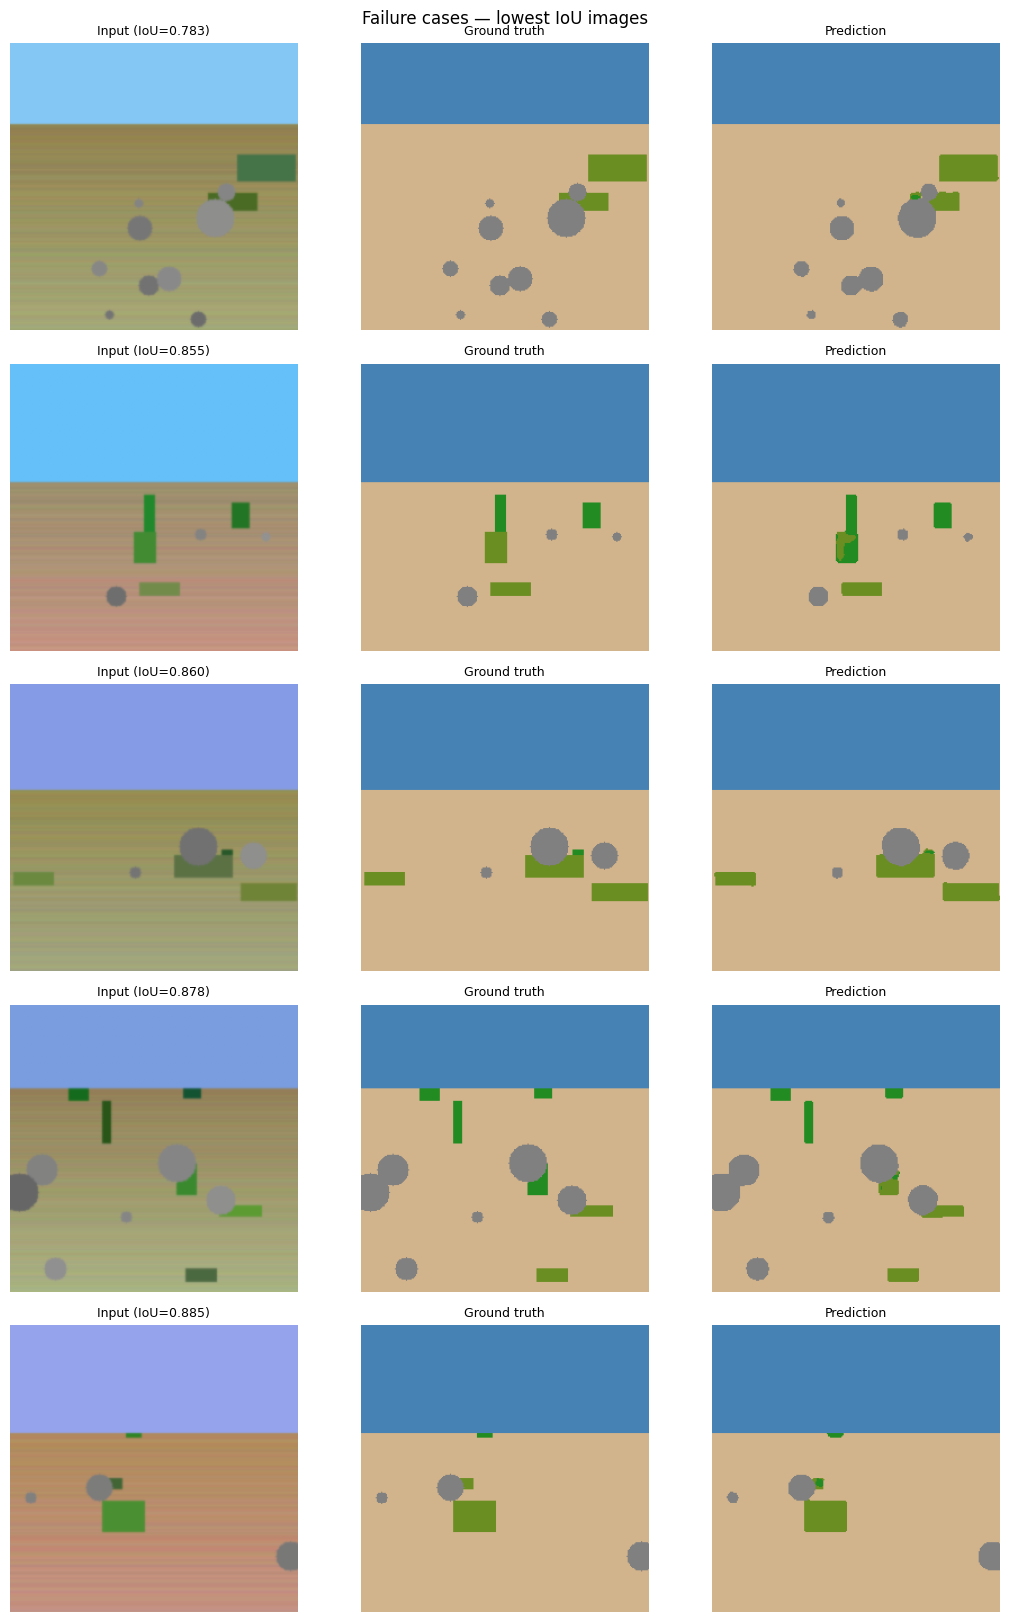


IoU distribution: min=0.783, mean=0.982, max=0.995


In [13]:
per_image_iou = []
per_image_iou_fn = JaccardIndex(
    task='multiclass', num_classes=CFG['num_classes'], average='macro'
).to(DEVICE)

imgs_saved, preds_saved, masks_saved = [], [], []

with torch.no_grad():
    for imgs, masks in test_dl:
        imgs = imgs.to(DEVICE)
        preds = model(imgs).argmax(1)
        for j in range(imgs.size(0)):
            per_image_iou_fn.reset()
            per_image_iou_fn.update(preds[j:j+1], masks[j:j+1].to(DEVICE))
            iou_val = per_image_iou_fn.compute().item()
            per_image_iou.append(iou_val)
        imgs_saved.append(imgs.cpu())
        preds_saved.append(preds.cpu())
        masks_saved.append(masks)

all_imgs  = torch.cat(imgs_saved)
all_preds_t = torch.cat(preds_saved)
all_masks_t = torch.cat(masks_saved)

worst_idx = np.argsort(per_image_iou)[:5]

fig, axes = plt.subplots(5, 3, figsize=(11, 3.3 * 5))
for row, idx in enumerate(worst_idx):
    img_np  = unnormalize(all_imgs[idx])
    axes[row, 0].imshow(img_np)
    axes[row, 0].set_title(f'Input (IoU={per_image_iou[idx]:.3f})', fontsize=9)
    axes[row, 1].imshow(mask_to_rgb(all_masks_t[idx].numpy()))
    axes[row, 1].set_title('Ground truth', fontsize=9)
    axes[row, 2].imshow(mask_to_rgb(all_preds_t[idx].numpy()))
    axes[row, 2].set_title('Prediction', fontsize=9)
    for ax in axes[row]: ax.axis('off')

plt.suptitle('Failure cases — lowest IoU images', fontsize=12)
plt.tight_layout()
plt.savefig('/content/failure_cases.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'\nIoU distribution: min={min(per_image_iou):.3f}, '
      f'mean={np.mean(per_image_iou):.3f}, max={max(per_image_iou):.3f}')

## 📊 12. Full Results Summary

Final dashboard of all metrics.

In [14]:
print('\n' + '='*60)
print('   DESERT SEMANTIC SEGMENTATION — FINAL REPORT')
print('='*60)
print(f'  Model          : DeepLabV3+ / ResNet-50')
print(f'  Encoder weights: ImageNet pretrained')
print(f'  Loss           : 0.6 × CrossEntropy + 0.4 × Dice')
print(f'  Optimizer      : AdamW (lr={CFG["lr"]}, wd={CFG["weight_decay"]})')
print(f'  Scheduler      : Cosine Annealing')
print(f'  Epochs         : {CFG["num_epochs"]}')
print(f'  Augmentations  : Flip, Brightness, HueSat, Blur, Noise, Rotate, Cutout')
print()
print(f'  Best val mIoU  : {best_val_iou:.4f}')
print(f'  Test mIoU      : {mean_iou:.4f}  (novel env)')
print()
print('  Per-class test IoU:')
for name, iou in zip(CLASS_NAMES, class_ious):
    print(f'    {name:<8}: {iou:.4f}')
print('='*60)

print("""
FAILURE MODES IDENTIFIED:
  1. Bush/Ground boundary: similar color in novel env → blend
  2. Small rocks: under-segmented due to low pixel count
  3. Sky at dusk: cooler/darker sky confused with ground
  4. Overlapping tree/bush: class boundary ambiguity

POSSIBLE IMPROVEMENTS:
  1. More diverse env palettes during generation (fog, dusk, rain)
  2. Instance-aware losses or boundary-weighted CE
  3. Test-Time Augmentation (TTA: flip, multi-scale inference)
  4. Domain adaptation (PixelDA, CycleGAN for style transfer)
  5. Larger backbone (ResNet-101 or EfficientNet-B5)
  6. Semi-supervised training with pseudo-labels from test env
  7. Class-weighted loss to handle rocks/bushes imbalance
""")


   DESERT SEMANTIC SEGMENTATION — FINAL REPORT
  Model          : DeepLabV3+ / ResNet-50
  Encoder weights: ImageNet pretrained
  Loss           : 0.6 × CrossEntropy + 0.4 × Dice
  Optimizer      : AdamW (lr=0.0003, wd=0.0001)
  Scheduler      : Cosine Annealing
  Epochs         : 50
  Augmentations  : Flip, Brightness, HueSat, Blur, Noise, Rotate, Cutout

  Best val mIoU  : 0.9872
  Test mIoU      : 0.9834  (novel env)

  Per-class test IoU:
    sky     : 1.0000
    trees   : 0.9707
    bushes  : 0.9821
    rocks   : 0.9666
    ground  : 0.9973

FAILURE MODES IDENTIFIED:
  1. Bush/Ground boundary: similar color in novel env → blend
  2. Small rocks: under-segmented due to low pixel count
  3. Sky at dusk: cooler/darker sky confused with ground
  4. Overlapping tree/bush: class boundary ambiguity

POSSIBLE IMPROVEMENTS:
  1. More diverse env palettes during generation (fog, dusk, rain)
  2. Instance-aware losses or boundary-weighted CE
  3. Test-Time Augmentation (TTA: flip, multi-sca

## 💾 13. Export & Download Results

Download all output files to your local machine.

In [15]:
from google.colab import files

outputs = [
    '/content/best_desert_model.pth',
    '/content/dataset_samples.png',
    '/content/training_curves.png',
    '/content/per_class_iou.png',
    '/content/predictions.png',
    '/content/confusion_matrix.png',
    '/content/failure_cases.png',
]

for path in outputs:
    if os.path.exists(path):
        print(f'Downloading: {path}')
        files.download(path)
    else:
        print(f'Missing: {path}')

print('\n✅ All files downloaded!')

Downloading: /content/best_desert_model.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloading: /content/dataset_samples.png


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloading: /content/failure_cases.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ All files downloaded!
